In [1]:
import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv, find_dotenv
import requests
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit
from pmdarima.arima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

For this analysis I use CPI data taken from the Federal Reserve Bank API. Reproduction of this analysis requires replacing the 'key' variable with an API key. Official documentation for the Federal Reserve Bank's API can be found here: https://fred.stlouisfed.org/docs/api/fred/.

In [2]:
#load environment and get cpi data
load_dotenv(find_dotenv())
key = os.getenv('fred_key')
series_id = 'CPIAUCSL'
fred_api_url = f'https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={key}&file_type=json'
response = requests.get(fred_api_url)
data = response.json()
print(data)

{'realtime_start': '2024-09-11', 'realtime_end': '2024-09-11', 'observation_start': '1600-01-01', 'observation_end': '9999-12-31', 'units': 'lin', 'output_type': 1, 'file_type': 'json', 'order_by': 'observation_date', 'sort_order': 'asc', 'count': 932, 'offset': 0, 'limit': 100000, 'observations': [{'realtime_start': '2024-09-11', 'realtime_end': '2024-09-11', 'date': '1947-01-01', 'value': '21.48'}, {'realtime_start': '2024-09-11', 'realtime_end': '2024-09-11', 'date': '1947-02-01', 'value': '21.62'}, {'realtime_start': '2024-09-11', 'realtime_end': '2024-09-11', 'date': '1947-03-01', 'value': '22.0'}, {'realtime_start': '2024-09-11', 'realtime_end': '2024-09-11', 'date': '1947-04-01', 'value': '22.0'}, {'realtime_start': '2024-09-11', 'realtime_end': '2024-09-11', 'date': '1947-05-01', 'value': '21.95'}, {'realtime_start': '2024-09-11', 'realtime_end': '2024-09-11', 'date': '1947-06-01', 'value': '22.08'}, {'realtime_start': '2024-09-11', 'realtime_end': '2024-09-11', 'date': '1947-0

In [3]:
#convert to pd
observations = data['observations']
df = pd.DataFrame(observations)

In [4]:
#view df
df

,realtime_start,realtime_end,date,value
0,2024-09-11,2024-09-11,1947-01-01,21.48
1,2024-09-11,2024-09-11,1947-02-01,21.62
2,2024-09-11,2024-09-11,1947-03-01,22.0
3,2024-09-11,2024-09-11,1947-04-01,22.0
4,2024-09-11,2024-09-11,1947-05-01,21.95
...,...,...,...,...
927,2024-09-11,2024-09-11,2024-04-01,313.207
928,2024-09-11,2024-09-11,2024-05-01,313.225
929,2024-09-11,2024-09-11,2024-06-01,313.049
930,2024-09-11,2024-09-11,2024-07-01,313.534


In [5]:
#change columns types
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df['value'] = pd.to_numeric(df['value'])

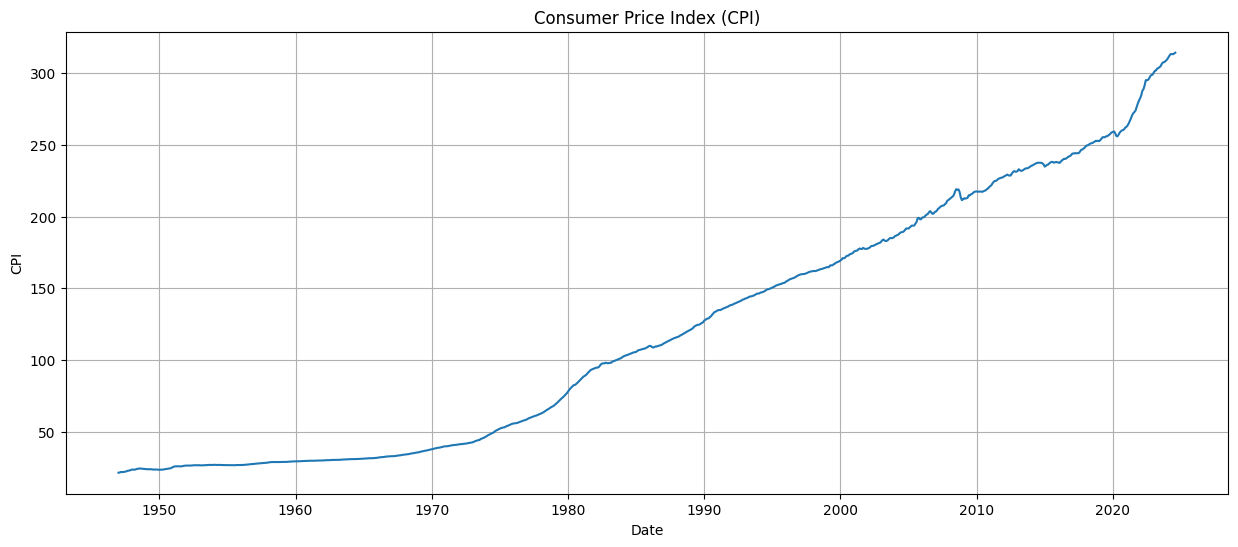

In [6]:
#line graph
plt.figure(figsize=(15, 6))
plt.plot(df['value'])
plt.title('Consumer Price Index (CPI)')
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('CPI')
plt.show()

Looking at the line chart above, we see that there is an obvious upward trend. This trend violates the assumption of consistency in means for any two similar lengths of time. In other words, the data is not stationary. To control for the violation of consistency of means, a differencing approach is applied.

In [7]:
#first-order differencing for stationarity
df['value_diff'] = df['value'].diff().dropna()

df.head()

#delete first year
df = df.iloc[12:]

In [8]:
df.head()

,realtime_start,realtime_end,value,value_diff
date,,,,
1948-01-01,2024-09-11,2024-09-11,23.68,0.27
1948-02-01,2024-09-11,2024-09-11,23.67,-0.01
1948-03-01,2024-09-11,2024-09-11,23.50,-0.17
1948-04-01,2024-09-11,2024-09-11,23.82,0.32
1948-05-01,2024-09-11,2024-09-11,24.01,0.19


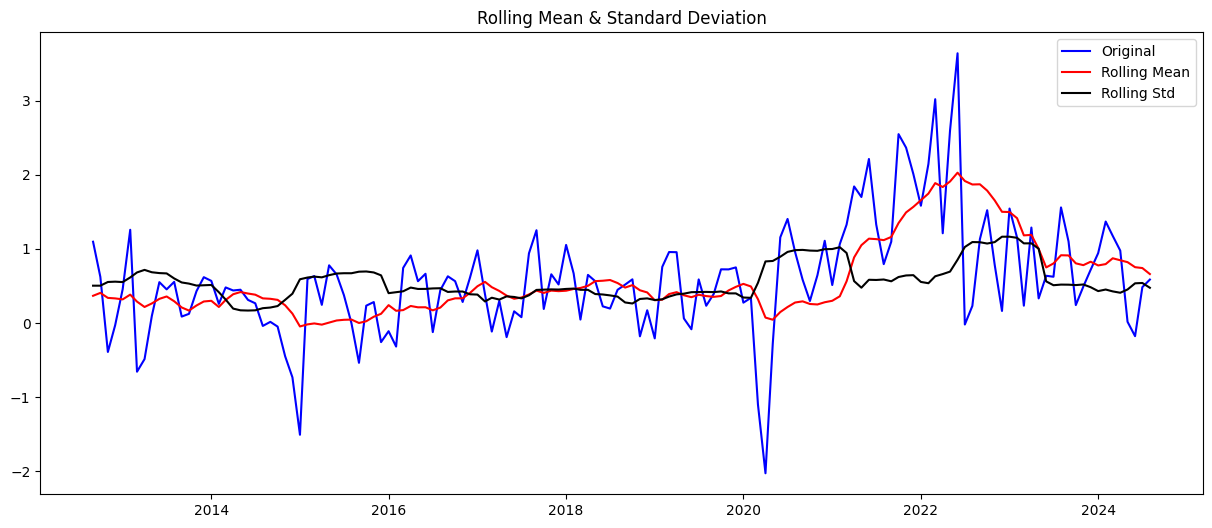

In [9]:
#12 month window
rolling_mean = df['value_diff'].rolling(window=12).mean()
rolling_std = df['value_diff'].rolling(window=12).std()

#12 years
df2 = df.tail(144)
rolling_mean = rolling_mean.tail(144)
rolling_std = rolling_std.tail(144)

#graph rolling mean and std. deviation
plt.figure(figsize=(15, 6))
plt.plot(df2['value_diff'], color='blue', label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean')
plt.plot(rolling_std, color='black', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

Based on the rolling mean and standard deviation line graph, first-order differencing may not adequately account for the lack of stationarity. An Augmented Dickey-Fuller (ADF) test is used below to quantitatively test for stationarity.

In [10]:
#check stationarity
adf_test = adfuller(df['value_diff'], autolag='AIC')
adf_results = pd.Series(adf_test[0:4], index=['ADF Statistic', 'P-value', 'Lags', 'Observations'])
for key, value in adf_test[4].items():
    adf_results[f'Critical Value at {key} level'] = value
print(adf_results)


ADF Statistic                   -3.845615
P-value                          0.002474
Lags                            14.000000
Observations                   905.000000
Critical Value at 1% level      -3.437596
Critical Value at 5% level      -2.864739
Critical Value at 10% level     -2.568473
dtype: float64


A p-value of 0.002 typically indicates statistical significance, which would mean that we reject the null hypothesis and that the time series has a unit root (i.e., is non-stationary). However, given the size of the dataset, adjusting the alpha level to .002 may not be unreasonable, which means that the model may benefit from second-order differencing. The ACF and PACF plots are used to approximate the number of auto regressive terms (p) and moving average terms (q) to include in the model. A search algorithm is also applied to find the best and non-seasonal and seasonal terms.

In [17]:
#ACF and PACF plots
#fig, axes = plt.subplots(1, 2, figsize=(16, 6))
#sm.graphics.tsa.plot_acf(df['value_diff'], lags=24, ax=axes[0])
#sm.graphics.tsa.plot_pacf(df['value_diff'], lags=24, ax=axes[1])
#plt.show()

#ARIMA

#search = auto_arima(df['value'], seasonal=False, m=12, trace=True, suppress_warnings=True, stepwise=True)

#print(search.summary())
#best model found to be ARIMA(0,2,3)(0,0,0)[0] with an AIC of 782.821

model = ARIMA(df['value'], order=(12, 1, 1))
results = model.fit()

print(results.summary())
#AIC 763.595, BIC 831.121


C:\Users\Cole Jones\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Cole Jones\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Cole Jones\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  920
Model:                ARIMA(12, 1, 1)   Log Likelihood                -367.798
Date:                Wed, 02 Oct 2024   AIC                            763.595
Time:                        15:04:19   BIC                            831.121
Sample:                    01-01-1948   HQIC                           789.365
                         - 08-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0127      0.139     -0.092      0.927      -0.285       0.260
ar.L2          0.2160      0.078      2.774      0.006       0.063       0.369
ar.L3         -0.0146      0.030     -0.481      0.6

In [21]:
#SARIMA

search1 = auto_arima(df['value'], seasonal=True, m=12, trace=True, suppress_warnings=True, stepwise=True)

print(search1.summary())
#best model found to be SARIMA(0,2,3)(2,0,0)[12] with an AIC of 762.403

model2 = SARIMAX(df['value'], order=(0, 2, 3), seasonal_order=(2, 0, 0, 12))
results2 = model2.fit()

print(results2.summary())

C:\Users\Cole Jones\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Cole Jones\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                               value   No. Observations:                  920
Model:             SARIMAX(0, 2, 3)x(2, 0, [], 12)   Log Likelihood                -375.201
Date:                             Wed, 02 Oct 2024   AIC                            762.403
Time:                                     15:07:57   BIC                            791.336
Sample:                                 01-01-1948   HQIC                           773.445
                                      - 08-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4234      0.013    -31.907      0.000      -0.449      -0.397
ma.L2         -0.3901      

The second-order differencing (d=2) is applied to the data and the model integrates the differenced forecasts back into the original scale. The result of the SARIMAX model is satisfactory. An AIC (Akaike Information Criterion) value of 763.681 concluded to be the lowest AIC value for a non-seasonal ARIMA model and 762.403 for a SARIMA model.

C:\Users\Cole Jones\AppData\Local\Temp\ipykernel_29852\131082451.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=df.index[-1], periods=24, freq='M')


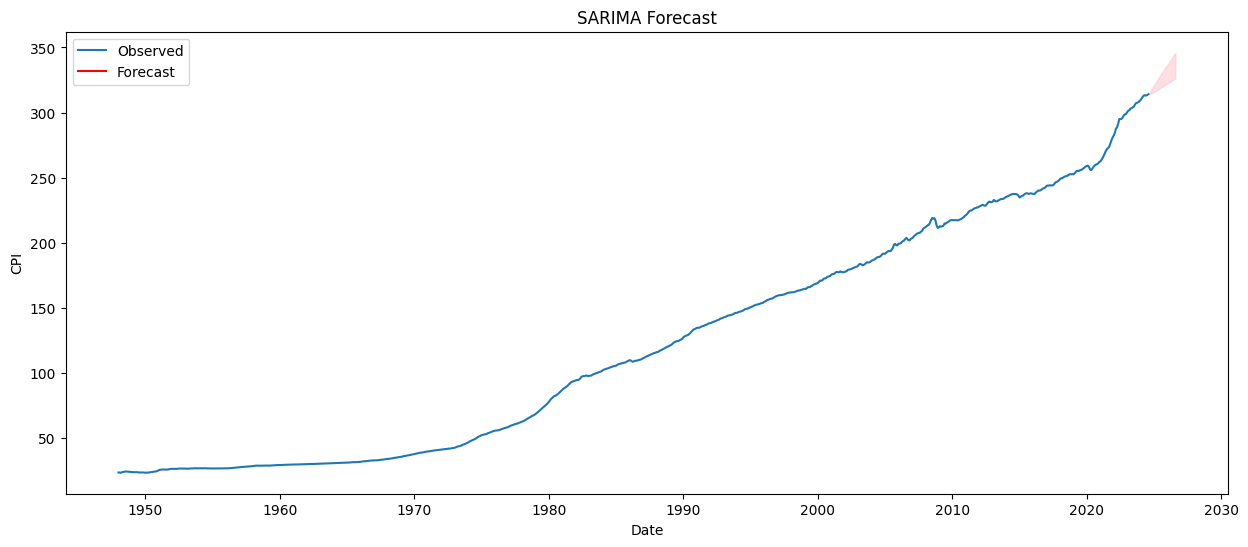

In [23]:
#visualize the SARIMA forecast
forecast = results2.get_forecast(steps=24)
forecast_index = pd.date_range(start=df.index[-1], periods=24, freq='M')
forecast_series = pd.Series(forecast.predicted_mean, index=forecast_index)

plt.figure(figsize=(15, 6))
plt.plot(df['value'], label='Observed')
plt.plot(forecast_series, label='Forecast', color='red')
plt.fill_between(forecast_index, forecast.conf_int().iloc[:, 0], forecast.conf_int().iloc[:, 1], color='pink', alpha=0.5)
plt.title('SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.legend()
plt.show()

C:\Users\Cole Jones\AppData\Local\Temp\ipykernel_29852\3497897426.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=df.index[-1], periods=24, freq='M')


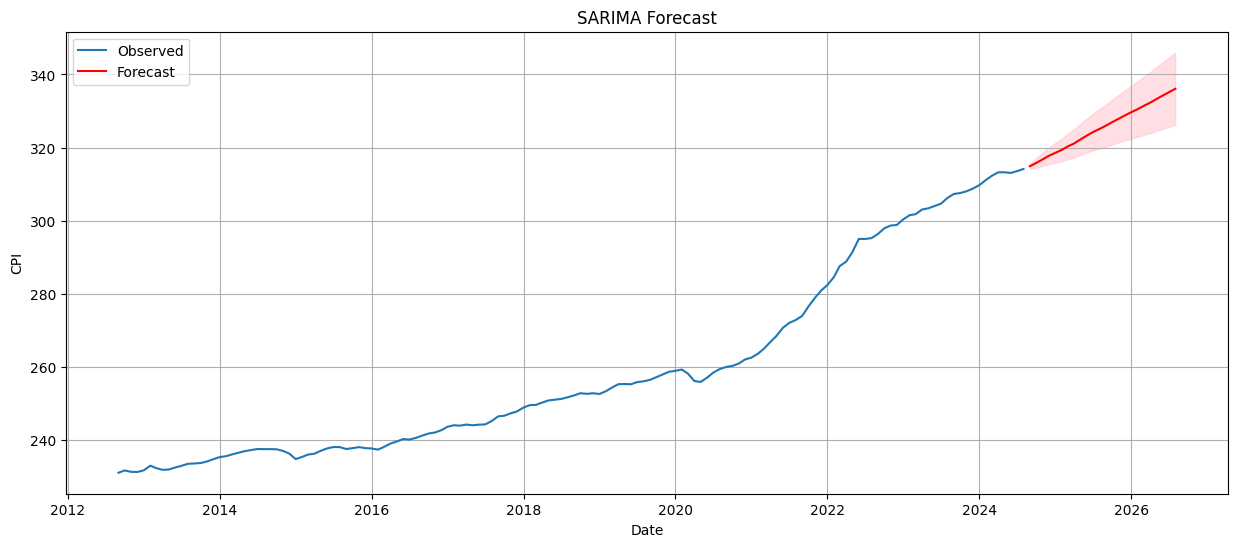

In [24]:
#visualize 10 years of historical data and the forecast
forecast = results2.get_forecast(steps=24)
forecast_index = pd.date_range(start=df.index[-1], periods=24, freq='M')
forecast_series = pd.Series(forecast.predicted_mean, index=forecast_index)

#confidence intervals and means of forecasts
conf_int = forecast.conf_int()
forecast_series = forecast.predicted_mean

#12 years
df2 = df.tail(144)

plt.figure(figsize=(15, 6))
plt.plot(df2['value'], label='Observed')
plt.plot(forecast_series, label='Forecast', color='red')
plt.fill_between(forecast_index, forecast.conf_int().iloc[:, 0], forecast.conf_int().iloc[:, 1], color='pink', alpha=0.5)
plt.title('SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid()
plt.legend()
plt.show()

Mean Absolute Percentage Error (MAPE): 0.14%


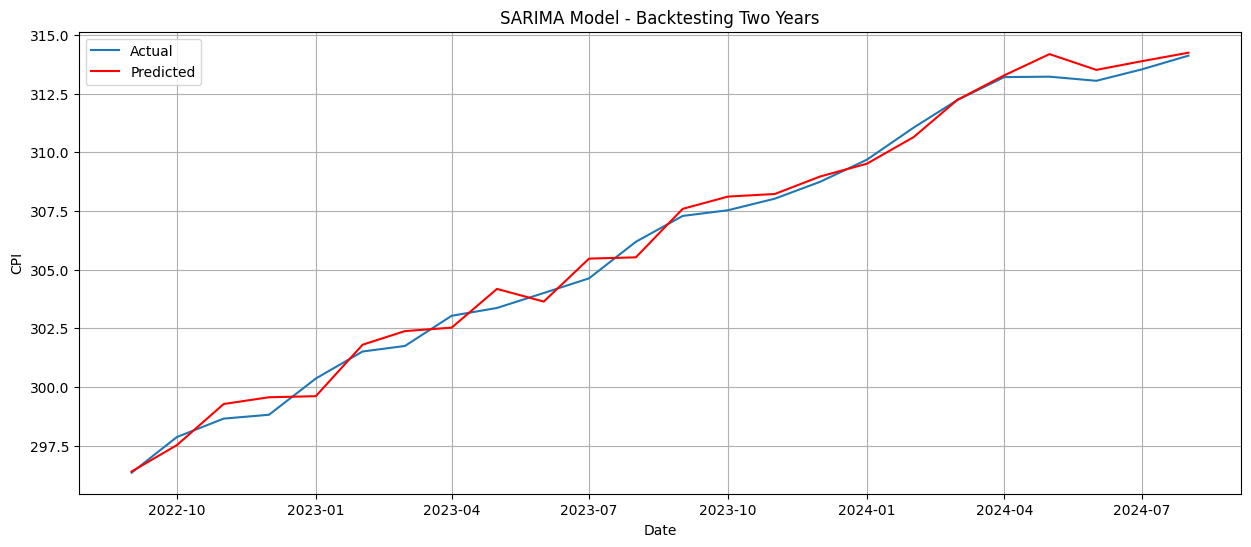

In [27]:
#backtest 2 years
n_test = 24
n_train = len(df) - n_test

#backtest split
train, test = df['value'].iloc[:n_train], df['value'].iloc[n_train:]


predictions = []

#walk-forward over the test set
history = list(train)
for t in range(n_test):
    model = SARIMAX(history, order=(0, 2, 3), seasonal_order=(2, 0, 0, 12))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    obs = test.iloc[t]
    history.append(obs)

#calculate MAPE
mape = np.mean(np.abs((test.values - predictions) / test.values)) * 100
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

#plot MAPE
plt.figure(figsize=(15, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, color='red', label='Predicted')
plt.title('SARIMA Model - Backtesting Two Years')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
#final df
forecast_df = pd.DataFrame({
    'Actuals': df['value'],
    'Forecast': forecast_series,
    'Lower CI': conf_int.iloc[:, 0],
    'Upper CI': conf_int.iloc[:, 1]
})

print(forecast_df.tail(30))

            Actuals    Forecast    Lower CI    Upper CI
2024-02-01  311.054         NaN         NaN         NaN
2024-03-01  312.230         NaN         NaN         NaN
2024-04-01  313.207         NaN         NaN         NaN
2024-05-01  313.225         NaN         NaN         NaN
2024-06-01  313.049         NaN         NaN         NaN
2024-07-01  313.534         NaN         NaN         NaN
2024-08-01      NaN  313.996555  313.289310  314.703800
2024-09-01      NaN  314.452645  313.116834  315.788457
2024-10-01      NaN  314.966735  313.116048  316.817422
2024-11-01      NaN  315.530579  313.233099  317.828059
2024-12-01      NaN  316.097620  313.362422  318.832818
2025-01-01      NaN  316.593552  313.419646  319.767459
2025-02-01      NaN  317.079094  313.478849  320.679338
2025-03-01      NaN  317.484858  313.442291  321.527425
2025-04-01      NaN  317.687251  313.173269  322.201233
2025-05-01      NaN  318.018265  313.036484  323.000046
2025-06-01      NaN  318.448163  312.970986  323